# PH 530: Light–Matter Interaction

## Project Topic  
**Practical Continuous-Variable Quantum Secret Sharing Using Local Local Oscillator**<br>
**Reference Link: https://www.nature.com/articles/s42005-025-02061-w**

---

## Team Members

1. **Aditya Saran** — 22B1839
2. **Akshay Chaturvedi** — 22B2432
3. **Kshitij Bahadarpurkar** — 22B1802
2. **Swaprabha Dey** — 22B1841
2. **Vedant Chaudhari** — 22B2481

---

## Implementation Part
We implement the data processing part as given in the paper which involves following components
<ol>
<li>Phase Compensation Method</li>
<li>Estimation of Transmission Coefficients (T1,T2)</li>
<li>Estimation of Mutual information and Maximum information available to Eavesdropper</li>
<li>Finding the secure key rate (R) based on the data and noise characteristics</li>
</ol>

## Contribution of Members


1. **Aditya Saran (22B1839):** The LLO-CQVSS setup and different stages of implementation
2. **Akshay Chaturvedi (22B2432):** Phase compensation method and data processing calculations
3. **Kshitij Bahadarpurkar (22B1802):** Jupyter notebook implementation of concepts and parameter fine tuning
4. **Swaprabha Dey (22B1841):** Error Analysis and its effects on the system, Discussion and Conclusion
5. **Vedant Chaudhari (22B2481):** Introduction, problem statement and key rate calculation


In [1]:
# Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Parameters

In [2]:
N=100000      # Number of bits sent
ETA=0.95      # Detection Efficiency (From reference)
T1=0.8        # Transmittance for user 1
T2=0.9        # Transmittance for user 2
BETA=0.95     # Reverse Reconcillation Efficiency (From reference)
V_U1=4        # User 1 Signal modulation variance (From reference)
V_U2=4        # User 2 Signal modulation variance (From reference)
V_EL=0.05     # Electronic noise for imperfect detector (From reference)

THETA_R_2=90  # Phase difference wrt user 2
THETA_R_D=45  # Phase difference wrt dealer

# Noise Params
NOISE_SLOW_1=0.005
NOISE_FAST_1=0.001
NOISE_SLOW_2=0.01
NOISE_FAST_2=0.05



## Generating Data in terms of x,p

In [3]:

# The code provides functionality to generate in a rotated ellipse like distribution to simulate complicated situations
sigma_x1 = 3 #np.sqrt(V_U1)
sigma_p1 = 1 #np.sqrt(V_U1)

x_base1 = np.random.normal(0, sigma_x1, N) # Different distribution across quadratures
p_base1 = np.random.normal(0, sigma_p1, N)

theta1 = np.pi / 3   # 30 degrees

x1 = x_base1 * np.cos(theta1) - p_base1 * np.sin(theta1) # Rotated ellipse
p1 = x_base1 * np.sin(theta1) + p_base1 * np.cos(theta1)

# -------- User 2 --------

sigma_x2 = 3 #np.sqrt(V_U2)
sigma_p2 = 1 #np.sqrt(V_U2)

x_base2 = np.random.normal(0, sigma_x2, N)
p_base2 = np.random.normal(0, sigma_p2, N)

theta2 = theta1 + np.pi / 2   # Rotated ellipse

x2 = x_base2 * np.cos(theta2) - p_base2 * np.sin(theta2)
p2 = x_base2 * np.sin(theta2) + p_base2 * np.cos(theta2)

def check_covariance(x, y, name=""):
    cov = np.mean((x - np.mean(x)) * (y - np.mean(y)))
    print(f"{name} Covariance: {cov:.6f}")
    return cov

# For the system to work, covariance between the users must be 0
check_covariance(x1, x2, "x1 vs x2");
check_covariance(p1, p2, "p1 vs p2");

x1 vs x2 Covariance: -0.000096
p1 vs p2 Covariance: -0.014665


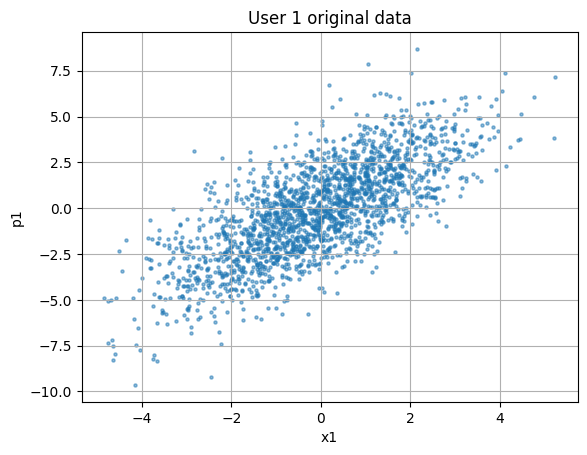

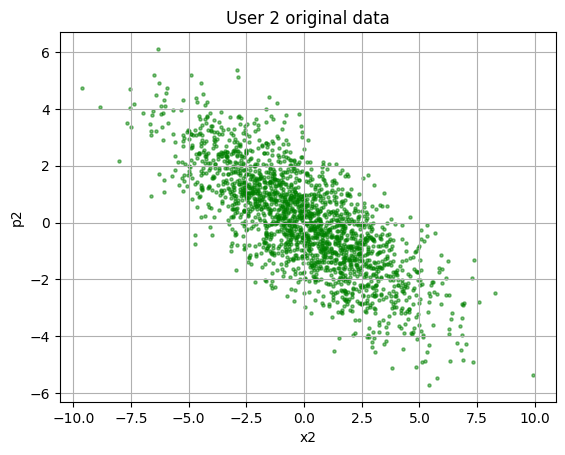

In [4]:
#  Visualising Data
#  Number of points to visualize
num_points = 2000

# ---- User 1 ----
plt.figure()
plt.scatter(x1[:num_points], p1[:num_points], s=5, alpha=0.5)
plt.title("User 1 original data")
plt.xlabel("x1")
plt.ylabel("p1")
plt.grid()
plt.show()

# ---- User 2 ----
plt.figure()
plt.scatter(x2[:num_points], p2[:num_points], s=5, alpha=0.5,c='g')
plt.title("User 2 original data")
plt.xlabel("x2")
plt.ylabel("p2")
plt.grid()
plt.show()

### Adding Noise and Phase Delay

In [5]:
# Rotation function
def rotate(x, p, theta_deg):
    """
    Rotate phase space variables (x, p) by angle theta (in degrees).

    Args:
        x, p : numpy arrays
        theta_deg : angle in degrees

    Returns:
        x_rot, p_rot : rotated variables
    """
    theta = np.deg2rad(theta_deg)

    x_rot = x * np.cos(theta) + p * np.sin(theta)
    p_rot = -x * np.sin(theta) + p * np.cos(theta)

    return x_rot, p_rot

def add_phase_drift(x, p, noise_slow, noise_fast):
    """
    Apply slow + fast phase drift.

    noise_slow: variance of slow drift (same to entire batch of data)
    noise_fast: variance of fast drift
    """
    N = len(x)

    # Slow drift (one value for whole block)
    theta_slow = np.random.normal(0, np.sqrt(noise_slow))

    # Fast drift (per sample)
    theta_fast = np.random.normal(0, np.sqrt(noise_fast), N)

    # Total phase
    theta_total = theta_slow + theta_fast

    # Apply rotation sample-wise
    x_new = x * np.cos(theta_total) + p * np.sin(theta_total)
    p_new = -x * np.sin(theta_total) + p * np.cos(theta_total)

    return x_new, p_new, theta_slow

# Applying noise in terms of rotation
x1, p1, theta_slow_1 = add_phase_drift(x1, p1, NOISE_SLOW_1, NOISE_FAST_1)
x2, p2, theta_slow_2 = add_phase_drift(x2, p2, NOISE_SLOW_2, NOISE_FAST_2)
x2, p2 = rotate(x2, p2, THETA_R_2) # Reference of user 2 is different from that of 1 so that effect


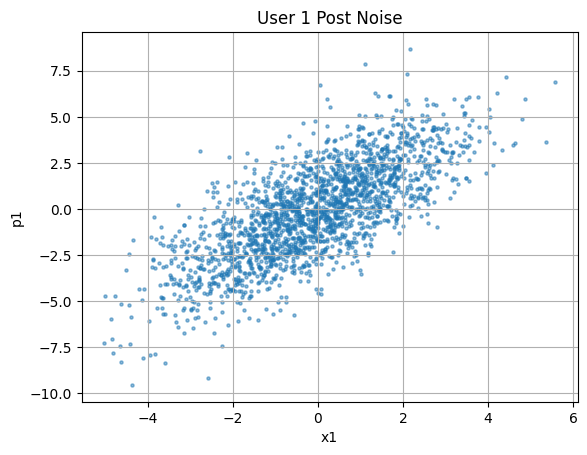

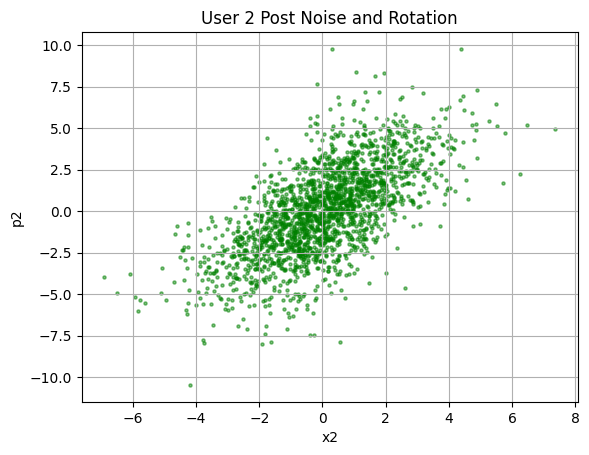

In [6]:
# ---- User 1  ----
plt.figure()
plt.scatter(x1[:num_points], p1[:num_points], s=5, alpha=0.5)
plt.title("User 1 Post Noise")
plt.xlabel("x1")
plt.ylabel("p1")
plt.grid()
plt.show()

# ---- User 2  ----
plt.figure()
plt.scatter(x2[:num_points], p2[:num_points], s=5, alpha=0.5,c='g')
plt.title("User 2 Post Noise and Rotation")
plt.xlabel("x2")
plt.ylabel("p2")
plt.grid()
plt.show()

## Detection by Detector and Further Processing

The detector receives the combined data from both users.  
The combination is affected by detector efficiency and channel transmittance of each user.



\begin{aligned}
x &= \sqrt{\frac{\eta T_1}{2}}\, x_{1} + \sqrt{\frac{\eta T_2}{2}}\, x_{2} + x_{N} \\
p &= \sqrt{\frac{\eta T_1}{2}}\, p_{1} + \sqrt{\frac{\eta T_2}{2}}\, p_{2} + p_{N}
\end{aligned}


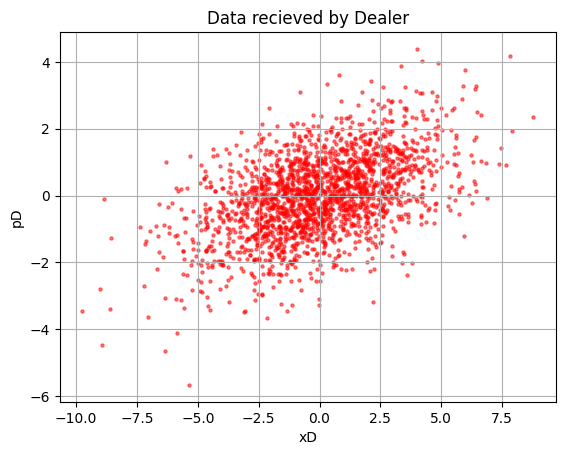

In [7]:
xD, pD = np.sqrt(0.5*ETA*T1)*x1 + np.sqrt(0.5*ETA*T2)*x2, np.sqrt(0.5*ETA*T1)*p1 + np.sqrt(0.5*ETA*T2)*p2
xD, pD = rotate(xD,pD,THETA_R_D) # Different reference alignment wrt detector

xD+=np.random.normal(0, np.sqrt(V_EL), N) # Adding noise
pD+=np.random.normal(0, np.sqrt(V_EL), N)

# ---- Dealer ----
plt.figure()
plt.scatter(xD[:num_points], pD[:num_points], s=5, alpha=0.5,c='r')
plt.title("Data recieved by Dealer")
plt.xlabel("xD")
plt.ylabel("pD")
plt.grid()
plt.show()

In [8]:
# Now we apply all the transformations
xD_p,pD_p = rotate(xD,pD,-1*THETA_R_D) # (Reference Eqn 9)
x2_p,p2_p = rotate(x2,p2,-1*THETA_R_2)

# Fractions of dividing data for T1, T2, R1, R2 calculation
f_est = 0.2
f_r1  = 0.1
f_r2  = 0.1

# Sizes
N_est = int(f_est * N)
N_r1  = int(f_r1 * N)
N_r2  = int(f_r2 * N)

# Shuffle indices
indices = np.random.permutation(N)

# Assign splits
est_idx = indices[:N_est]

r1_idx = indices[N_est : N_est + N_r1]

r2_idx = indices[N_est + N_r1 : N_est + N_r1 + N_r2]

key_idx = indices[N_est + N_r1 + N_r2:]

# Part of data to compute T1, T2
x1_test=x1[est_idx]
p1_test=p1[est_idx]

x2_test=x2_p[est_idx]
p2_test=p2_p[est_idx]

xD_test=xD_p[est_idx]
pD_test=pD_p[est_idx]

### Calculating Phase Delay
The phase delay that occurs during transmission can be subverted by the shared shared between users and the dealer. The formulas used are (also given in the reference)

\begin{aligned}
\Delta \theta_{D1}^{\text{delay}} &= \tan^{-1}\!\left( \frac{\langle p_{1} x_{D}^{\prime} \rangle}{\langle x_{1} x_{D}^{\prime} \rangle} \right) \\
\Delta \theta_{D2}^{\text{delay}} &= \tan^{-1}\!\left( \frac{\langle p_{2}^{\prime} x_{D}^{\prime} \rangle}{\langle x_{2}^{\prime} x_{D}^{\prime} \rangle} \right)
\end{aligned}



In [9]:
# Extracting Angles

THETA_DELAY_1 = np.arctan2(np.mean(p1_test * xD_test), np.mean(x1_test * xD_test)) # (Reference Eqn 14)
THETA_DELAY_2 = np.arctan2(np.mean(p2_test * xD_test), np.mean(x2_test * xD_test)) # (Reference Eqn 15)

#Now use them to modify the data
x1_p,p1_p=rotate(x1,p1,THETA_DELAY_1)
x2_pp,p2_pp=rotate(x2_p,p2_p,THETA_DELAY_2)

print(f"Theta delay 1: {THETA_DELAY_1}")
print(f"Theta delay 2: {THETA_DELAY_2}")

Theta delay 1: 0.8408575268265915
Theta delay 2: 2.3574160953288725


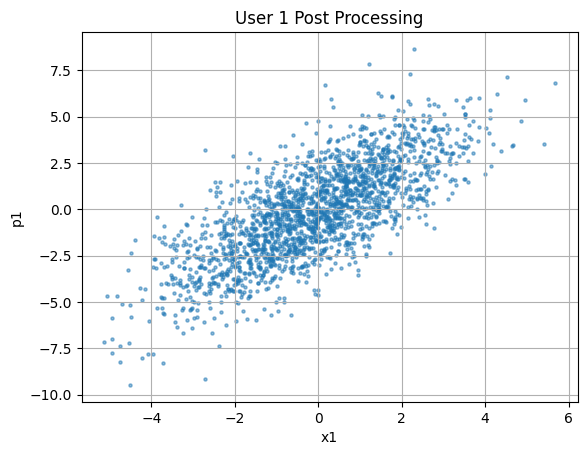

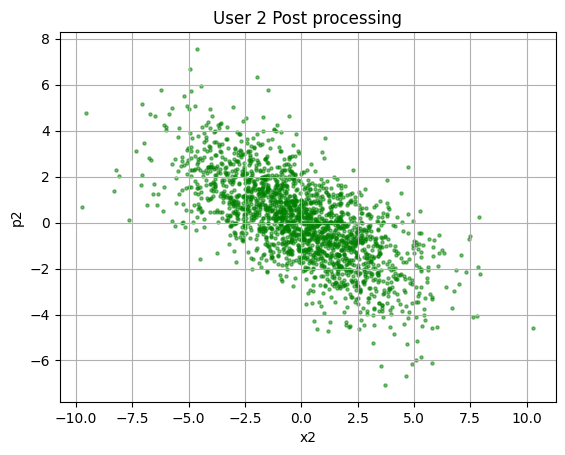

In [10]:
# ---- User 1 Post process ----
plt.figure()
plt.scatter(x1_p[:num_points], p1_p[:num_points], s=5, alpha=0.5)
plt.title("User 1 Post Processing")
plt.xlabel("x1")
plt.ylabel("p1")
plt.grid()
plt.show()

# ---- User 2 Post process ----
plt.figure()
plt.scatter(x2_pp[:num_points], p2_pp[:num_points], s=5, alpha=0.5,c='g')
plt.title("User 2 Post processing")
plt.xlabel("x2")
plt.ylabel("p2")
plt.grid()
plt.show()

### Channel Transmittance Calculation

Based on the data shared between the users we can calculate the Transmittance of each channel given as

$$
T_{i} = \frac{2}{\eta} \left( \frac{\langle x_{i} x_{D} \rangle}{\langle x_{i} x_{i} \rangle} \right)^2
$$

In [11]:
# Finding T1
cov_x1_xD = np.mean(x1_test * xD_test) # Taking covariance as <x1,x2> is 0 x2 data will not affect it
var_x1 = np.var(x1_test)

T1_est = (cov_x1_xD ** 2) / (0.5 * ETA * (var_x1 ** 2))
print(f"Estimated T1: {T1_est}")
print(f"Actual T1: {T1}")

Estimated T1: 0.8082716484968013
Actual T1: 0.8


In [12]:
# Finding T2
cov_x2_xD = np.mean(x2[est_idx] * xD_test)
var_x2 = np.var(x2[est_idx])

T2_est = (cov_x2_xD ** 2) / (0.5 * ETA * (var_x2 ** 2))
print(f"Estimated T2: {T2_est}")
print(f"Actual T2: {T2}")

Estimated T2: 0.9020456160724513
Actual T2: 0.9


## Computing channel noise $\epsilon$

In [13]:
# Parameters (Taken from the paper)
A_SMAX1 = np.sqrt(10*V_U1) # User 1 Max amplitude (From reference)
A_SMAX2 = np.sqrt(10*V_U2) # User 2 Max amplitude (From reference)

D_DB = 40 # Finite dynamic of AM (From reference)
Q=10 # Quantization Bit number of ADC (From reference)
E_CH =0.002 # Channel Noise of Phase reference (From reference)



In [14]:
# Epsilon calculation as given in reference

# Amplitude Modulation Noise
eps_am_1 = A_SMAX1**2*(10**(-0.1*D_DB))
eps_am_2=  A_SMAX2**2*(10**(-0.1*D_DB))*(T2/T1)
eps_am=eps_am_1+eps_am_2

# Analog to digtical converter noise
eps_adc=(1/(12*2**Q))*(A_SMAX1**2+A_SMAX2**2*(T2/T1))

# Phase noise
eps_phase=NOISE_SLOW_1+NOISE_SLOW_2+NOISE_FAST_1+NOISE_FAST_2

# Total Noise
epsilon=eps_am+eps_adc+eps_phase

print(f"Epsilon (noise): {epsilon}")


Epsilon (noise): 0.08141731770833334


## Computing R1, R2

In [15]:
# Helper functions for calculating chi_de
# Function are from formulas in reference section : "Secret key rate calculation of LLO-CVQSS"
def G(x):
    x = np.maximum(x, 1e-12)
    return (x+1)*np.log2(x+1) - x*np.log2(x)

def chi_de(V,T,chi_line,chi_het,chi_tot):

    A=V*V*(1-2*T)+2*T+(T*(V+chi_line))**2
    B=(T*(V*chi_line+1))**2

    l1=np.sqrt(0.5*(A+np.sqrt(A**2-4*B)))
    l2=np.sqrt(0.5*(A-np.sqrt(A**2-4*B)))

    C=(A*chi_het**2+B+1+2*chi_het*(V*np.sqrt(B)+T*(V+chi_line))+2*T*(V*V-1))/(T*(V+chi_tot))**2
    D=((V+np.sqrt(B)*chi_het)/(T*(V+chi_tot)))**2

    l3=np.sqrt(0.5*(C+np.sqrt(C**2-4*D)))
    l4=np.sqrt(0.5*(C-np.sqrt(C**2-4*D)))
    l5=1

    ans=G(0.5*(l1-1))+G(0.5*(l2-1))-G(0.5*(l3-1))-G(0.5*(l4-1))-G(0.5*(l5-1))
    return ans

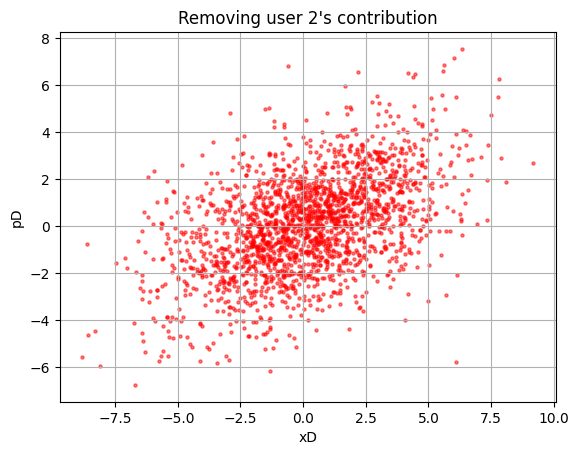

In [16]:
#R1 Calculation

xD_R1=xD_p[r1_idx] # Use proper data points
pD_R1=pD_p[r1_idx]

x1_R1=x1_p[r1_idx]
p1_R1=p1_p[r1_idx]

x2_R1 = x2_pp[r1_idx]
p2_R1 = p2_pp[r1_idx]

# Remove user 2 contribution
xD1 = xD_R1 - np.sqrt(0.5*ETA*T2_est) * x2_R1
pD1 = pD_R1 - np.sqrt(0.5*ETA*T2_est) * p2_R1

# ---- Dealer ----
plt.figure()
plt.scatter(xD1[:num_points], pD1[:num_points], s=5, alpha=0.5,c='r')
plt.title("Removing user 2's contribution")
plt.xlabel("xD")
plt.ylabel("pD")
plt.grid()
plt.show()


In [17]:
# Pre computed epsilon
epsilon_1 = epsilon

chi_line_1 = (1 / T1_est) - 1 + epsilon_1 # (Reference Eqn 30)
chi_het_1 = (2 - ETA + 2 * V_EL) / ETA  # (Reference Eqn 31)

chi_tot_1 = chi_line_1 + (chi_het_1 / T1_est) # (Reference Eqn 32)



In [18]:
# Applying final formula
I_UD_1 = np.log2((V_U1 + chi_tot_1) / (1 + chi_tot_1)) # (Reference Eqn 33)
chi_de_1=chi_de(V_U1+1,T1_est,chi_line_1,chi_het_1,chi_tot_1)
R1 = BETA * I_UD_1 - chi_de_1 # (Reference Eqn 29)
print(f"Value of R1 is {R1}")

Value of R1 is 0.13612324186019487


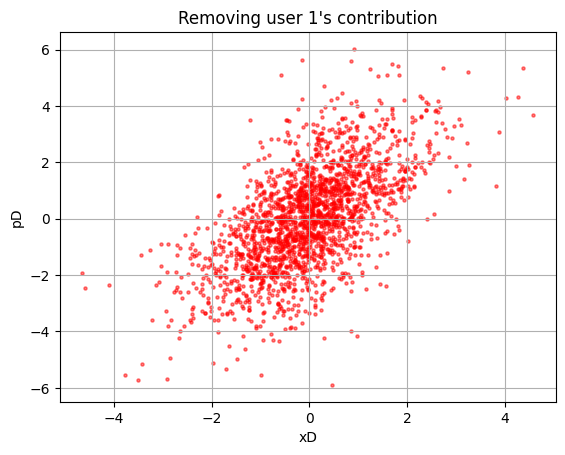

In [19]:
# Same process as R1 but for R2

xD_R2=xD_p[r2_idx]
pD_R2=pD_p[r2_idx]

x1_R2=x1_p[r2_idx]
p1_R2=p1_p[r2_idx]

x2_R2 = x2_pp[r2_idx]
p2_R2 = p2_pp[r2_idx]

# Remove user 1 contribution
xD2 = xD_R2 - np.sqrt(0.5*ETA*T1_est) * x1_R2
pD2 = pD_R2 - np.sqrt(0.5*ETA*T1_est) * p1_R2

# ---- Dealer ----
plt.figure()
plt.scatter(xD2[:num_points], pD2[:num_points], s=5, alpha=0.5,c='r')
plt.title("Removing user 1's contribution")
plt.xlabel("xD")
plt.ylabel("pD")
plt.grid()
plt.show()


In [20]:
# Epsilon from earlier
epsilon_2 = epsilon

chi_line_2 = (1 / T2_est) - 1 + epsilon_2
chi_het_2 = (2 - ETA + 2 * V_EL) / ETA

chi_tot_2 = chi_line_2 + (chi_het_2 / T2_est)


In [21]:
I_UD_2 = np.log2((V_U2 + chi_tot_2) / (1 + chi_tot_2))
chi_de_2=chi_de(V_U2+1,T2_est,chi_line_2,chi_het_2,chi_tot_2)
R2 = BETA * I_UD_2 - chi_de_2
print(f"Value of R2 is {R2}")

Value of R2 is 0.25257715654910695


## Finding R

In [22]:
R=min(R1,R2)
print(f"Value of R which is min(R1,R2): {R}")

Value of R which is min(R1,R2): 0.13612324186019487


With now R available we know what fraction of data is reliable, further Quantum Error Correction Algorithms can be applied to extract the key for User 1 and User 2 which can be used to encrypt the messages